In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

dfs = []
for year in [2013, 2014, 2015, 2016, 2017]:
    for month in range(1, 13):
        if month == 12:
            next_year, next_month = year + 1, 1
        else:
            next_year, next_month = year, month + 1
        start = f"{year}-{month:02d}-01"
        end   = f"{next_year}-{next_month:02d}-01"
        url = (
            f"https://data.cityofchicago.org/resource/ijzp-q8t2.csv"
            f"?$select=date,primary_type,latitude,longitude,district"
            f"&$where=date>='{start}'%20AND%20date<'{end}'"
            f"&$limit=30000&$order=date%20ASC"
        )
        temp = pd.read_csv(url)
        temp['year']  = year
        temp['month'] = month
        dfs.append(temp)
        print(f"  {year}-{month:02d}: {len(temp)} rows")

df = pd.concat(dfs, ignore_index=True)
print("\nFinal shape:", df.shape)

  2013-01: 25573 rows
  2013-02: 21430 rows
  2013-03: 25000 rows
  2013-04: 25547 rows
  2013-05: 28026 rows
  2013-06: 27404 rows
  2013-07: 28647 rows
  2013-08: 28679 rows
  2013-09: 26363 rows
  2013-10: 25494 rows
  2013-11: 23577 rows
  2013-12: 21880 rows
  2014-01: 20105 rows
  2014-02: 18055 rows
  2014-03: 22205 rows
  2014-04: 22946 rows
  2014-05: 24895 rows
  2014-06: 25468 rows
  2014-07: 26587 rows
  2014-08: 25910 rows
  2014-09: 23912 rows
  2014-10: 24015 rows
  2014-11: 20785 rows
  2014-12: 20997 rows
  2015-01: 21019 rows
  2015-02: 16410 rows
  2015-03: 21693 rows
  2015-04: 21745 rows
  2015-05: 23731 rows
  2015-06: 23197 rows
  2015-07: 24248 rows
  2015-08: 24832 rows
  2015-09: 23140 rows
  2015-10: 23115 rows
  2015-11: 20606 rows
  2015-12: 21157 rows
  2016-01: 20803 rows
  2016-02: 18761 rows
  2016-03: 22075 rows
  2016-04: 21192 rows
  2016-05: 23561 rows
  2016-06: 24097 rows
  2016-07: 24871 rows
  2016-08: 24941 rows
  2016-09: 23711 rows
  2016-10:

In [ ]:
from sklearn.preprocessing import LabelEncoder

df.columns = df.columns.str.lower().str.strip()
df['date']  = pd.to_datetime(df['date'])
df = df.dropna(subset=['latitude', 'longitude'])

df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month

le = LabelEncoder()
df['crime_code'] = le.fit_transform(df['primary_type'])

print("Cleaned shape:", df.shape)
print("Year range:", df['year'].min(), "–", df['year'].max())
df.head()

Cleaned shape: (1370236, 10)
Year range: 2013 – 2017


,date,primary_type,latitude,longitude,district,year,month,hour,day_of_week,crime_code
6,2013-01-01,OFFENSE INVOLVING CHILDREN,41.856100,-87.726094,10.0,2013,1,0,1,21
16,2013-01-01,OFFENSE INVOLVING CHILDREN,41.882259,-87.763674,15.0,2013,1,0,1,21
17,2013-01-01,DECEPTIVE PRACTICE,41.721194,-87.663966,22.0,2013,1,0,1,9
18,2013-01-01,CRIMINAL DAMAGE,41.757529,-87.634470,6.0,2013,1,0,1,6
19,2013-01-01,BURGLARY,41.702049,-87.537704,4.0,2013,1,0,1,3


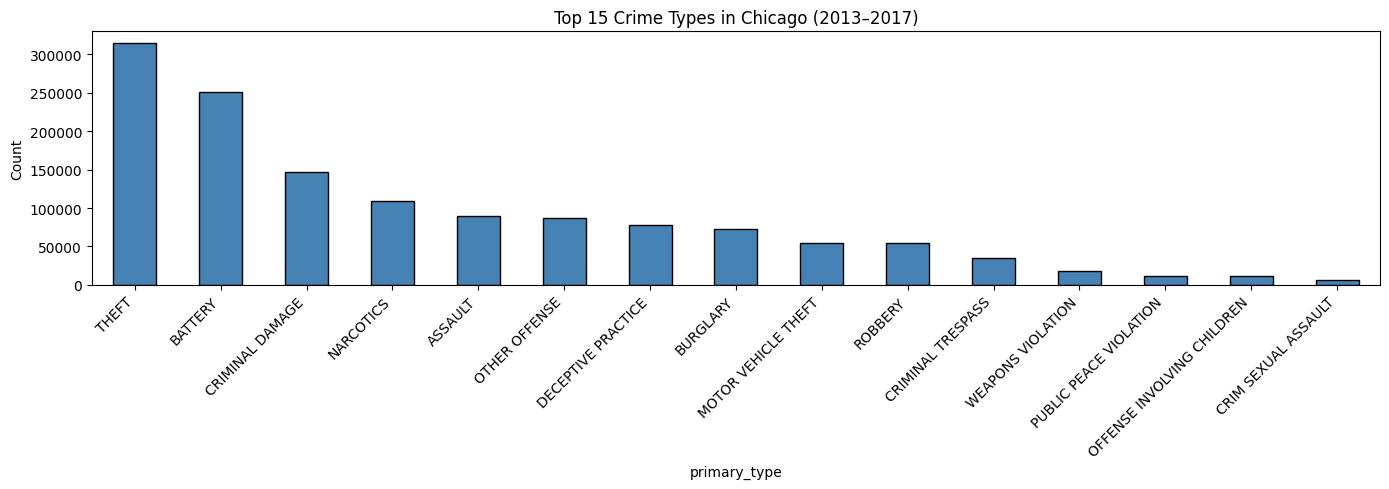

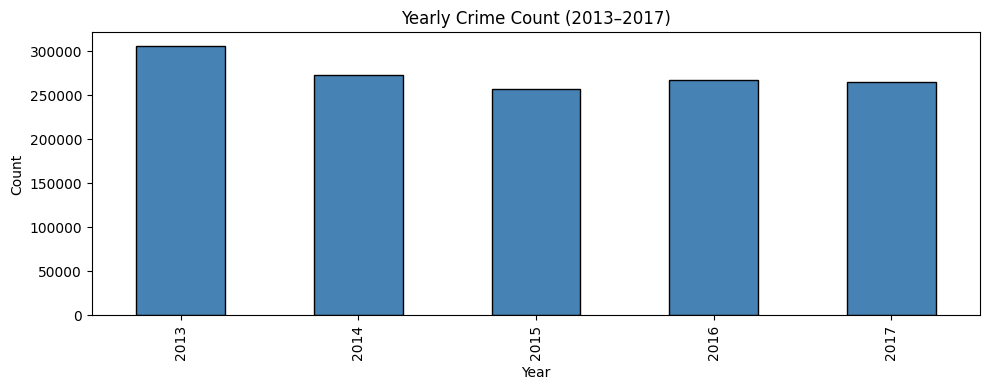

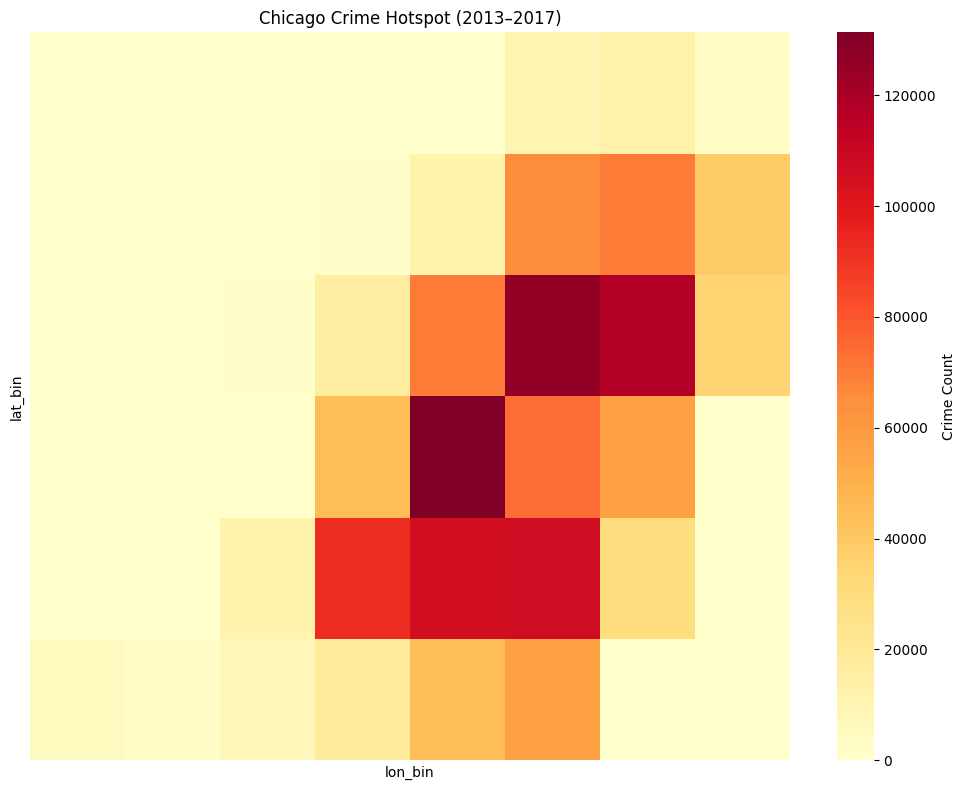

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Top 15 crime types
plt.figure(figsize=(14, 5))
df['primary_type'].value_counts().head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Crime Types in Chicago (2013–2017)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crime_types.png', dpi=150)
plt.show()

# Chart 2: Yearly trend
plt.figure(figsize=(10, 4))
df.groupby('year').size().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Yearly Crime Count (2013–2017)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150)
plt.show()

# Chart 3: Hotspot heatmap
lat_bins = np.linspace(df['latitude'].min(),  df['latitude'].max(),  80)
lon_bins = np.linspace(df['longitude'].min(), df['longitude'].max(), 80)
df['lat_bin'] = pd.cut(df['latitude'],  bins=lat_bins, labels=False)
df['lon_bin'] = pd.cut(df['longitude'], bins=lon_bins, labels=False)
grid = df.groupby(['lat_bin', 'lon_bin']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(grid, cmap='YlOrRd', linewidths=0,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Crime Count'})
plt.title('Chicago Crime Hotspot (2013–2017)')
plt.tight_layout()
plt.savefig('hotspot_map.png', dpi=150)
plt.show()

In [ ]:
# Aggregate to monthly crime counts
monthly = df.groupby(['year', 'month']).size().reset_index(name='crime_count')
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly = monthly.sort_values('date').reset_index(drop=True)

# Cyclical month encoding
monthly['month_sin'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month'] / 12)

# ✅ Lag features — these carry time-series memory
monthly['lag_1']    = monthly['crime_count'].shift(1)   # previous month
monthly['lag_2']    = monthly['crime_count'].shift(2)   # 2 months ago
monthly['lag_12']   = monthly['crime_count'].shift(12)  # same month last year
monthly['rolling3'] = monthly['crime_count'].rolling(3).mean()  # 3-month avg

monthly = monthly.dropna().reset_index(drop=True)

print("Monthly rows after lag dropna:", len(monthly))
print(monthly[['date', 'crime_count', 'lag_1', 'lag_12', 'rolling3']].head(8))

Monthly rows after lag dropna: 48
        date  crime_count    lag_1   lag_12      rolling3
0 2014-01-01        19749  21792.0  25325.0  21677.333333
1 2014-02-01        17942  19749.0  21361.0  19827.666667
2 2014-03-01        22081  17942.0  24897.0  19924.000000
3 2014-04-01        22785  22081.0  25469.0  20936.000000
4 2014-05-01        24771  22785.0  27945.0  23212.333333
5 2014-06-01        25299  24771.0  27296.0  24285.000000
6 2014-07-01        26437  25299.0  28573.0  25502.333333
7 2014-08-01        25727  26437.0  28581.0  25821.000000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Scale features
feature_cols = ['crime_count', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_12', 'rolling3']
feat_scaler = MinMaxScaler()
scaled = feat_scaler.fit_transform(monthly[feature_cols])

# Separate scaler for crime_count ONLY (needed to inverse-transform predictions)
target_scaler = MinMaxScaler()
crime_scaled = target_scaler.fit_transform(monthly[['crime_count']])

SEQ_LEN = 6  # ✅ Reduced from 12 → more training samples

def create_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(len(features) - seq_len):
        X.append(features[i : i + seq_len])       # shape: (seq_len, n_features)
        y.append(target[i + seq_len])              # scalar: next crime count
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, crime_scaled, SEQ_LEN)
print("X shape:", X.shape)   # expect (~41, 6, 7)
print("y shape:", y.shape)

# ✅ TIME-SERIES SPLIT — last 10 samples as validation (never shuffle!)
split = len(X) - 10
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
print(f"\nTrain samples: {len(X_train)}, Val samples: {len(X_val)}")

X shape: (42, 6, 7)
y shape: (42, 1)

Train samples: 32, Val samples: 10


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 6, 64)          │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,569 (60.82 KB)

 Trainable params: 15,569 (60.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.2312 - mae: 0.4483 - val_loss: 0.1185 - val_mae: 0.3134 - learning_rate: 0.0010
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0771 - mae: 0.2284 - val_loss: 0.0227 - val_mae: 0.1281 - learning_rate: 0.0010
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0545 - mae: 0.1810 - val_loss: 0.0203 - val_mae: 0.1272 - learning_rate: 0.0010
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0428 - mae: 0.1654 - val_loss: 0.0149 - val_mae: 0.1053 - learning_rate: 0.0010
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0398 - mae: 0.1622 - val_loss: 0.0156 - val_mae: 0.1037 - learning_rate: 0.0010
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0340 - mae: 0.1508 - val_loss: 0.0118 - val_mae: 0.0903 - learning_rate: 0.0010
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0256 - mae: 0.1255 - val_loss: 0.0075 - val_mae: 0.0767 - learning_rate: 0.0010
Epoch 8/300
8/8 ━━━

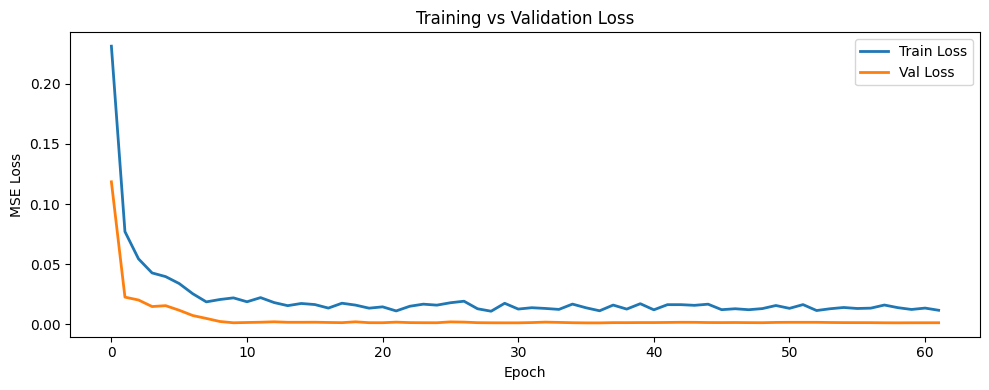

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

n_features = X.shape[2]  # 7 features

# ✅ Smaller model — right-sized for ~31 training samples
model = Sequential([
    Bidirectional(LSTM(32, return_sequences=True), input_shape=(SEQ_LEN, n_features)),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.1),
    Dense(8, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
model.summary()

early_stop = EarlyStopping(
    monitor='val_loss', patience=25,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=10, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=4,        # ✅ Small batch for small dataset
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
MAE:  280.62
RMSE: 376.77
R²:   0.9359

Month-by-month comparison (validation set):
Month        Actual    Predicted      Error
------------------------------------------
1             20385        20389          4
2             21486        21551         65
3             23177        22766        411
4             23577        23821        244
5             24608        24317        291
6             24428        24187        241
7             22538        23466        928
8             22487        22263        224
9             20972        21007         35
10            20349        19986        363


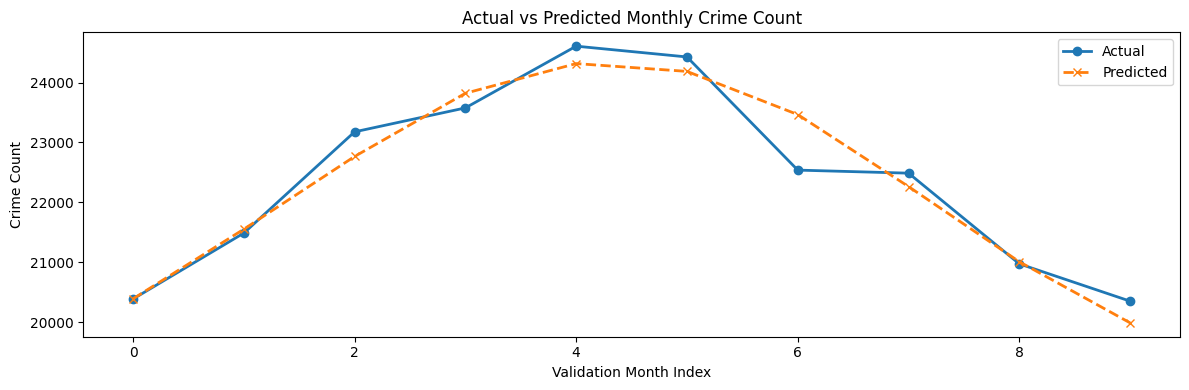

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_scaled = model.predict(X_val)

# ✅ Use target_scaler (fitted only on crime_count)
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_val)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# Month-by-month table
print("\nMonth-by-month comparison (validation set):")
print(f"{'Month':<8} {'Actual':>10} {'Predicted':>12} {'Error':>10}")
print("-" * 42)
for i, (a, p) in enumerate(zip(y_true.flatten(), y_pred.flatten())):
    print(f"{i+1:<8} {a:>10.0f} {p:>12.0f} {abs(a-p):>10.0f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 4))
plt.plot(y_true,  label='Actual',    marker='o', linewidth=2)
plt.plot(y_pred,  label='Predicted', marker='x', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Monthly Crime Count')
plt.xlabel('Validation Month Index')
plt.ylabel('Crime Count')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()


6-Month Forecast:
Month          Predicted Crimes
--------------------------------
Jan 2018                  19455
Feb 2018                  19534
Mar 2018                  20535
Apr 2018                  22026
May 2018                  23540
Jun 2018                  24425


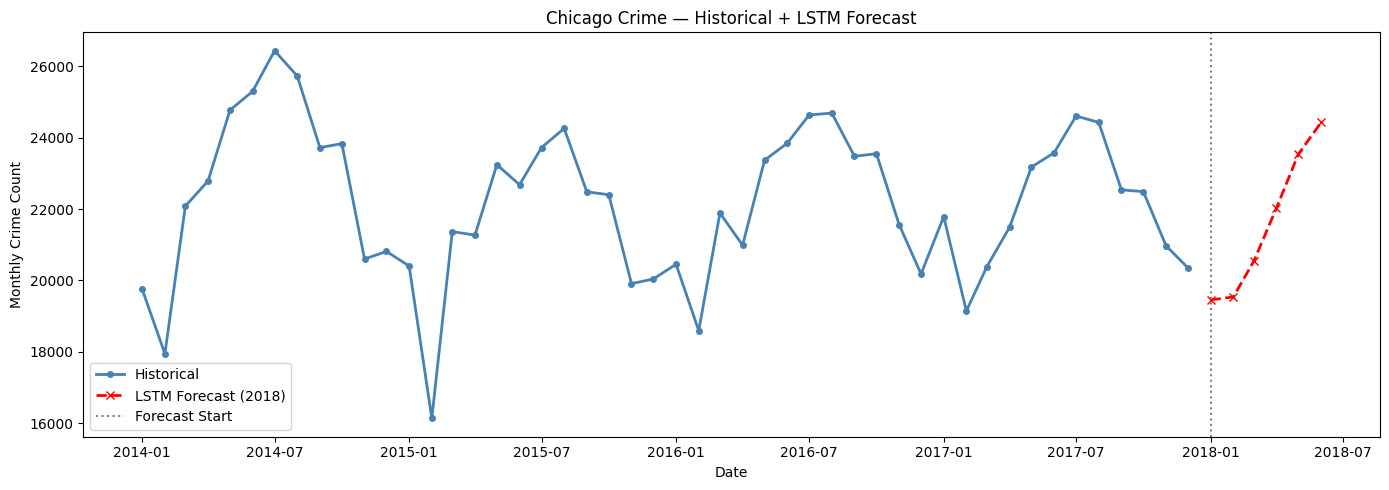

In [ ]:
# Build last sequence from all features
last_seq = scaled[-SEQ_LEN:].copy()  # shape: (6, 7)
future_preds = []

for step in range(6):
    inp = last_seq.reshape(1, SEQ_LEN, n_features)
    next_scaled = model.predict(inp, verbose=0)[0, 0]
    future_preds.append(next_scaled)

    # Build next feature row
    month_num = ((len(monthly) + step) % 12) + 1
    m_sin = np.sin(2 * np.pi * month_num / 12)
    m_cos = np.cos(2 * np.pi * month_num / 12)
    lag_1    = last_seq[-1, 0]
    lag_2    = last_seq[-2, 0]
    lag_12   = last_seq[-6, 0] if len(last_seq) >= 6 else last_seq[0, 0]
    rolling3 = np.mean(last_seq[-3:, 0])

    new_row = np.array([next_scaled, m_sin, m_cos, lag_1, lag_2, lag_12, rolling3])
    last_seq = np.vstack([last_seq[1:], new_row])

future_preds_actual = target_scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
)

future_months = ['Jan 2018', 'Feb 2018', 'Mar 2018',
                 'Apr 2018', 'May 2018', 'Jun 2018']

print("\n6-Month Forecast:")
print(f"{'Month':<12} {'Predicted Crimes':>18}")
print("-" * 32)
for m, p in zip(future_months, future_preds_actual):
    print(f"{m:<12} {p[0]:>18.0f}")

# Final chart: historical + forecast
all_actual   = target_scaler.inverse_transform(crime_scaled)
future_dates = pd.date_range(start='2018-01-01', periods=6, freq='MS')

plt.figure(figsize=(14, 5))
plt.plot(monthly['date'], all_actual,
         label='Historical', color='steelblue', linewidth=2, marker='o', markersize=4)
plt.plot(future_dates, future_preds_actual,
         label='LSTM Forecast (2018)', color='red', linewidth=2, marker='x', linestyle='--')
plt.axvline(x=pd.Timestamp('2018-01-01'), color='gray', linestyle=':', label='Forecast Start')
plt.title('Chicago Crime — Historical + LSTM Forecast')
plt.xlabel('Date')
plt.ylabel('Monthly Crime Count')
plt.legend()
plt.tight_layout()
plt.savefig('final_forecast.png', dpi=150)
plt.show()

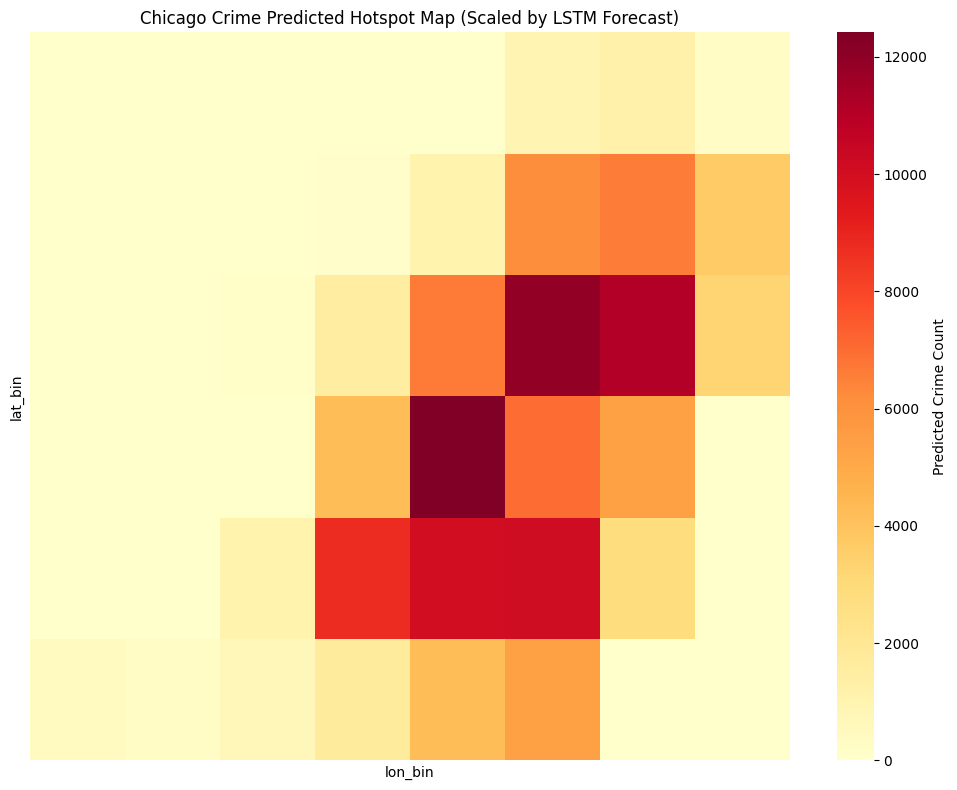

In [ ]:
# Calculate total historical crimes from the main DataFrame
total_historical_crimes = len(df)

# Calculate total forecasted crimes for the future period
total_predicted_future_crimes = future_preds_actual.sum()

# Calculate the scaling factor
scaling_factor = total_predicted_future_crimes / total_historical_crimes

# Create the predicted hotspot grid by scaling the historical grid
# The 'grid' variable from previous cells already holds the historical crime counts per bin.
predicted_hotspot_grid = grid * scaling_factor

plt.figure(figsize=(10, 8))
sns.heatmap(predicted_hotspot_grid, cmap='YlOrRd', linewidths=0,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Predicted Crime Count'})
plt.title('Chicago Crime Predicted Hotspot Map (Scaled by LSTM Forecast)')
plt.tight_layout()
plt.savefig('predicted_hotspot_map.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
   Month  Actual  Predicted  Error  Abs Error  Error %
Mar 2017   20385      20388      3          3      0.0
Apr 2017   21486      21551     65         65      0.3
May 2017   23177      22765   -411        411     -1.8
Jun 2017   23577      23821    244        244      1.0
Jul 2017   24608      24316   -291        291     -1.2
Aug 2017   24428      24186   -241        241     -1.0
Sep 2017   22538      23465    927        927      4.1
Oct 2017   22487      22262   -224        224     -1.0
Nov 2017   20972      21007     35         35      0.2
Dec 2017   20349      19986   -362        362     -1.8


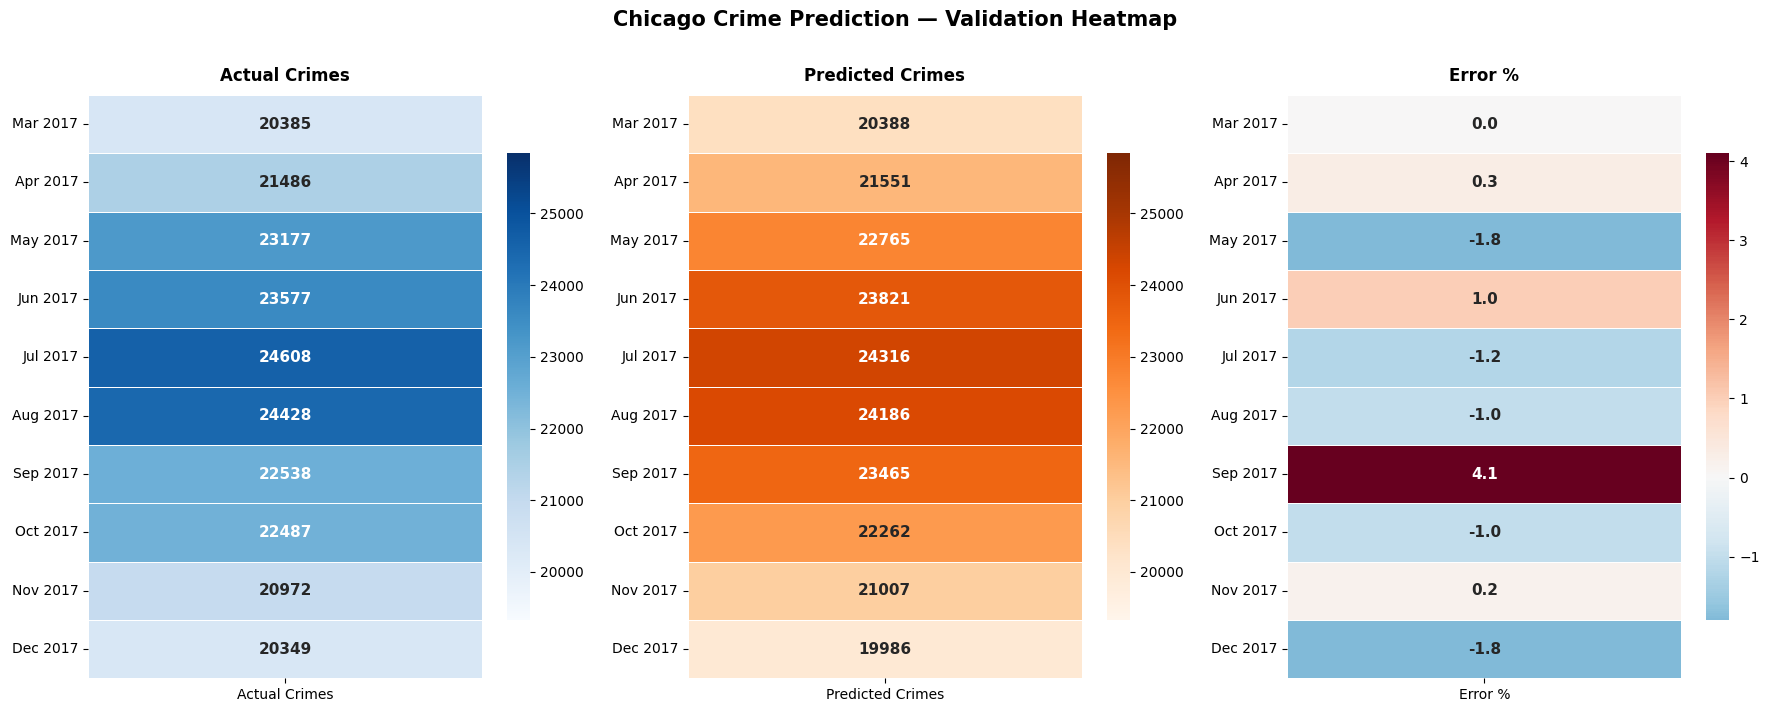

In [ ]:
# Cell 9 — Actual vs Predicted Heatmap

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Get all predictions on validation set
y_pred_scaled = model.predict(X_val)
y_pred = target_scaler.inverse_transform(y_pred_scaled).flatten()
y_true = target_scaler.inverse_transform(y_val).flatten()

# Build a comparison dataframe
val_months = monthly['date'].iloc[split + SEQ_LEN:].reset_index(drop=True)

# If lengths mismatch, generate labels manually
if len(val_months) != len(y_true):
    val_months = pd.date_range(start='2017-03-01', periods=len(y_true), freq='MS')

compare_df = pd.DataFrame({
    'Month':     [d.strftime('%b %Y') for d in val_months],
    'Actual':    y_true.astype(int),
    'Predicted': y_pred.astype(int),
    'Error':     (y_pred - y_true).astype(int),
    'Abs Error': np.abs(y_pred - y_true).astype(int),
    'Error %':   np.round(((y_pred - y_true) / y_true) * 100, 1)
})

print(compare_df.to_string(index=False))

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(y_true) * 0.55 + 1.5)))
fig.suptitle('Chicago Crime Prediction — Validation Heatmap', fontsize=15, fontweight='bold', y=1.01)

months_labels = compare_df['Month'].tolist()

def make_heatmap(ax, data, title, fmt, cmap, vmin=None, vmax=None, center=None):
    arr = np.array(data).reshape(-1, 1)
    sns.heatmap(
        arr, ax=ax,
        annot=True, fmt=fmt, cmap=cmap,
        yticklabels=months_labels, xticklabels=[title],
        linewidths=0.5, linecolor='white',
        vmin=vmin, vmax=vmax, center=center,
        annot_kws={'size': 11, 'weight': 'bold'},
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(axis='y', labelsize=10, rotation=0)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_xlabel('')

# Panel 1: Actual crime counts
make_heatmap(axes[0], compare_df['Actual'],
             'Actual Crimes', 'd', 'Blues',
             vmin=compare_df['Actual'].min() * 0.95,
             vmax=compare_df['Actual'].max() * 1.05)

# Panel 2: Predicted crime counts
make_heatmap(axes[1], compare_df['Predicted'],
             'Predicted Crimes', 'd', 'Oranges',
             vmin=compare_df['Actual'].min() * 0.95,
             vmax=compare_df['Actual'].max() * 1.05)

# Panel 3: Error % (diverging — red = overpredict, blue = underpredict)
make_heatmap(axes[2], compare_df['Error %'],
             'Error %', '.1f', 'RdBu_r',
             center=0)

plt.tight_layout()
plt.savefig('prediction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

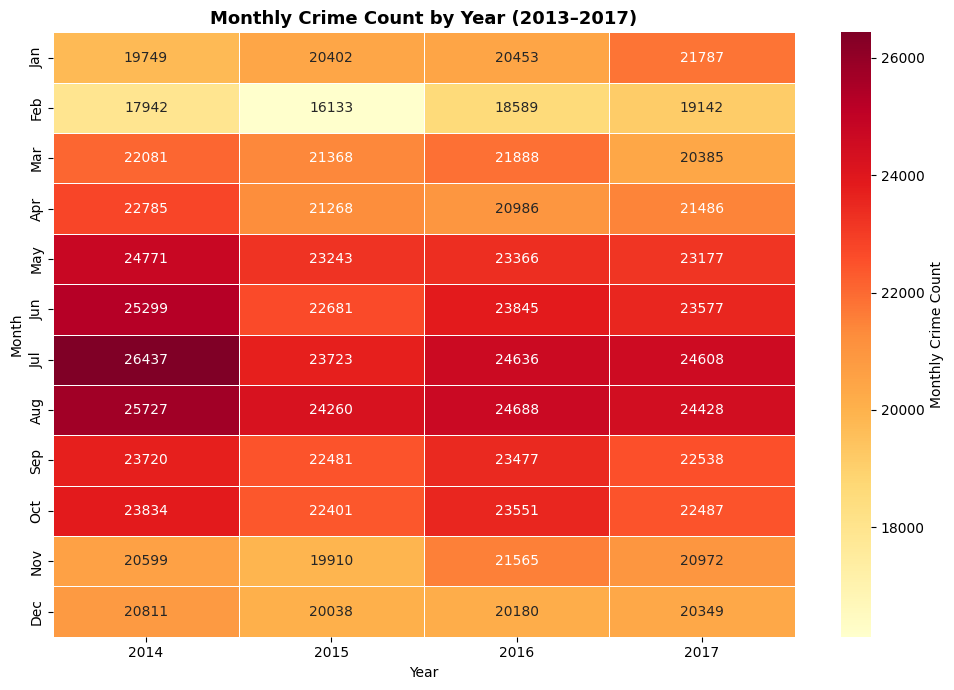

In [ ]:
# Bonus — Full historical heatmap (month × year grid)
pivot = monthly.pivot_table(values='crime_count', index='month', columns='year')
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10},
            cbar_kws={'label': 'Monthly Crime Count'})
plt.title('Monthly Crime Count by Year (2013–2017)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig('historical_heatmap.png', dpi=150)
plt.show()

In [ ]:
import folium
# Removed HeatMap as GeoJson will be used for interactive hotspots
from IPython.display import IFrame
import matplotlib.cm as cm
import matplotlib.colors as colors
from branca.colormap import linear

In [ ]:
chicago_center_lat = df['latitude'].mean()
chicago_center_lon = df['longitude'].mean()
m = folium.Map(location=[chicago_center_lat, chicago_center_lon], zoom_start=10)

In [ ]:
heatmap_data = []

for lat_bin_idx in predicted_hotspot_grid.index:
    for lon_bin_idx in predicted_hotspot_grid.columns:
        predicted_crime_count = predicted_hotspot_grid.loc[lat_bin_idx, lon_bin_idx]

        if predicted_crime_count > 0:
            lat_center = (lat_bins[int(lat_bin_idx)] + lat_bins[int(lat_bin_idx) + 1]) / 2
            lon_center = (lon_bins[int(lon_bin_idx)] + lon_bins[int(lon_bin_idx) + 1]) / 2
            heatmap_data.append([lat_center, lon_center, predicted_crime_count])

In [ ]:
# Re-initialize map to ensure a clean base for new layers
chicago_center_lat = df['latitude'].mean()
chicago_center_lon = df['longitude'].mean()
m = folium.Map(location=[chicago_center_lat, chicago_center_lon], zoom_start=10)

# Create a FeatureGroup to hold the interactive polygons
feature_group = folium.FeatureGroup(name="Predicted Crime Hotspots (Hoverable)")

# Determine min/max crime counts for coloring and normalization
if not predicted_hotspot_grid.empty and predicted_hotspot_grid.max().max() > 0:
    positive_counts = predicted_hotspot_grid[predicted_hotspot_grid > 0]
    min_count = positive_counts.min().min() if not positive_counts.empty else 0
    max_count = predicted_hotspot_grid.max().max()
else:
    min_count = 0
    max_count = 1 # Default to avoid division by zero or error with empty grid

cmap = cm.get_cmap('YlOrRd') # Yellow-Orange-Red colormap
norm = colors.Normalize(vmin=min_count, vmax=max_count if max_count > min_count else min_count + 1)

def style_function(feature):
    crime_count = int(float(feature['properties']['crime_count']))
    rgba_color = cmap(norm(crime_count))
    hex_color = colors.to_hex(rgba_color)
    return {
        'fillColor': hex_color,
        'color': 'black', # Border color
        'weight': 0.1,    # Border thickness
        'fillOpacity': 0.7
    }

geojson_features = []
# Iterate through the predicted_hotspot_grid to create GeoJSON polygons for each bin
for lat_bin_idx in predicted_hotspot_grid.index:
    for lon_bin_idx in predicted_hotspot_grid.columns:
        predicted_crime_count = predicted_hotspot_grid.loc[lat_bin_idx, lon_bin_idx]

        if predicted_crime_count > 0:
            lat_south = lat_bins[int(lat_bin_idx)]
            lat_north = lat_bins[int(lat_bin_idx) + 1]
            lon_west = lon_bins[int(lon_bin_idx)]
            lon_east = lon_bins[int(lon_bin_idx) + 1]

            polygon = {
                "type": "Feature",
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [[
                        [lon_west, lat_south],
                        [lon_east, lat_south],
                        [lon_east, lat_north],
                        [lon_west, lat_north],
                        [lon_west, lat_south] # Close the polygon
                    ]]
                },
                "properties": {
                    "crime_count": f"{predicted_crime_count:.0f}" # Store as string for tooltip
                }
            }
            geojson_features.append(polygon)

# Add GeoJSON to the feature group with tooltips and styling
folium.GeoJson(
    {
        "type": "FeatureCollection",
        "features": geojson_features
    },
    tooltip=folium.GeoJsonTooltip(fields=['crime_count'], aliases=['Predicted Crime Count:'], localize=True),
    style_function=style_function
).add_to(feature_group)

feature_group.add_to(m)

# Add a LayerControl to toggle the feature group if needed
folium.LayerControl().add_to(m)

# Add a color bar legend (ledger)
colormap = linear.YlOrRd_04.scale(vmin=min_count, vmax=max_count)
colormap.caption = 'Predicted Crime Count'
m.add_child(colormap)


map_filename = 'chicago_future_hotspot_folium_map_interactive_geojson.html'
m.save(map_filename)

print(f"Interactive Folium map saved to {map_filename}")

m # Display the map

Interactive Folium map saved to chicago_future_hotspot_folium_map_interactive_geojson.html
